<a href="https://colab.research.google.com/github/eshajain-123/csot-ml-astronomy/blob/main/week1_data_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:

import os
import random
from pathlib import Path

import pandas as pd
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torchvision
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [4]:
!mkdir -p ~/.kaggle
!echo "KGAT_5f9501c0011427d341b466ff0b47def7" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

In [5]:
!pip install -U kaggle
!kaggle datasets list -s galaxy-zoo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 24.8 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2
ref                                       title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
jaimetrickz/galaxy-zoo-2-images           Galaxy Zoo 2: Images                           3281862708  2021-01-26 16:25:27.667000           8623         34  0.9411765        


In [6]:
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images

Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [02:55<00:00, 18.7MB/s]



In [8]:
from pathlib import Path

RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2" / "images"
DATA_ROOT = Path("galaxy_data")

# RAW_ROOT.mkdir(exist_ok=True)
# IMAGES_DIR.mkdir(exist_ok=True)

In [9]:
!unzip -q -o galaxy-zoo-2-images.zip -d galaxy_raw

In [10]:
!wget -q -O galaxy_raw/gz2_hart16.csv.gz https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz
!gunzip -f galaxy_raw/gz2_hart16.csv.gz

In [11]:
print(RAW_ROOT)
print(IMAGES_DIR)

jpgs = list(IMAGES_DIR.glob("*.jpg"))
print("Number of images:", len(jpgs))
print("First image:", jpgs[0])

galaxy_raw
galaxy_raw/images_gz2/images
Number of images: 243434
First image: galaxy_raw/images_gz2/images/129893.jpg


In [12]:
!ls galaxy_raw
!ls galaxy_raw/images_gz2 | head

gz2_filename_mapping.csv  gz2_hart16.csv  images_gz2
images


In [13]:
!ls galaxy_raw/images_gz2/images | head

100000.jpg
100001.jpg
100002.jpg
100003.jpg
100004.jpg
100005.jpg
100006.jpg
100007.jpg
100008.jpg
10000.jpg


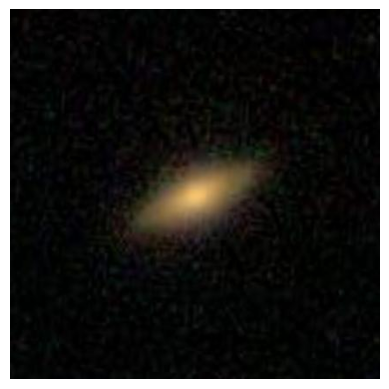

In [14]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(jpgs[0])

plt.imshow(img)
plt.axis("off")
plt.show()

In [15]:
from pathlib import Path
import pandas as pd

RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2" / "images"
DATA_ROOT = Path("galaxy_data")

print("RAW_ROOT contents:", sorted(p.name for p in RAW_ROOT.iterdir()))

jpg_count = sum(1 for _ in IMAGES_DIR.glob("*.jpg"))
print(f"Flat JPG count in {IMAGES_DIR}: {jpg_count:,}")

mapping_head = pd.read_csv(RAW_ROOT / "gz2_filename_mapping.csv", nrows=3)
print(mapping_head)

RAW_ROOT contents: ['gz2_filename_mapping.csv', 'gz2_hart16.csv', 'images_gz2']
Flat JPG count in galaxy_raw/images_gz2/images: 243,434
                objid    sample  asset_id
0  587722981736120347  original         1
1  587722981736579107  original         2
2  587722981741363294  original         3


In [16]:
def high_level_label(gz2_class: str):
    """Collapse detailed GZ2 morphology codes to a few training buckets."""
    if not gz2_class or gz2_class == "A":
        return None  # artifact / ambiguous — skip
    if gz2_class.startswith("E"):
        return "elliptical"
    if gz2_class.startswith("SB"):
        return "spiral_barred"
    if gz2_class.startswith("S"):
        return "spiral"
    return None


def build_imagefolder_layout(
    images_dir,
    mapping_csv,
    labels_csv,
    out_root,
    per_class=200,
    seed=42,
):
    """Symlink a balanced subset into out_root// for ImageFolder."""
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv).rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"])

    images_dir = Path(images_dir)
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    counts = {}
    for label in sorted(df["label"].unique()):
        class_dir = out_root / label
        class_dir.mkdir(exist_ok=True)
        rows = df[df["label"] == label]
        if len(rows) > per_class:
            rows = rows.sample(n=per_class, random_state=seed)
        linked = 0
        for _, row in rows.iterrows():
            src = images_dir / f"{int(row.asset_id)}.jpg"
            dst = class_dir / f"{int(row.asset_id)}.jpg"
            if src.exists() and not dst.exists():
                os.symlink(src.resolve(), dst)
                linked += 1
        counts[label] = linked
    return counts

PER_CLASS = 200  # balanced subset — fast on Colab; increase once the pipeline works
counts = build_imagefolder_layout(
    IMAGES_DIR,
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
    DATA_ROOT,
    per_class=PER_CLASS,
)
print("Symlinked per class:", counts)
print("DATA_ROOT classes:", sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir()))

Symlinked per class: {'elliptical': 200, 'spiral': 200, 'spiral_barred': 200}
DATA_ROOT classes: ['elliptical', 'spiral', 'spiral_barred']


In [17]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

In [18]:


dataset = ImageFolder(root=DATA_ROOT, transform=transform)
print("num images   :", len(dataset))
print("classes      :", dataset.classes)
print("class_to_idx :", dataset.class_to_idx)

num images   : 600
classes      : ['elliptical', 'spiral', 'spiral_barred']
class_to_idx : {'elliptical': 0, 'spiral': 1, 'spiral_barred': 2}


In [19]:


image, label = dataset[0]
print("shape :", image.shape)   # torch.Size([3, 64, 64])
print("dtype :", image.dtype)   # torch.float32
print("label :", label, "->", dataset.classes[label])

shape : torch.Size([3, 64, 64])
dtype : torch.float32
label : 0 -> elliptical


In [20]:


loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)

images, labels = next(iter(loader))
print("images:", images.shape)
print("labels:", labels.shape)

images: torch.Size([32, 3, 64, 64])
labels: torch.Size([32])


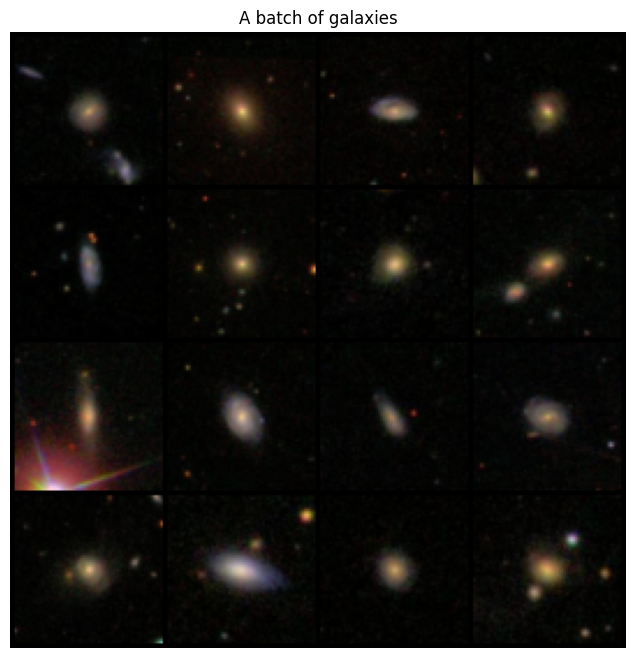

Labels: ['spiral_barred', 'elliptical', 'spiral', 'spiral_barred', 'spiral_barred', 'elliptical', 'elliptical', 'spiral_barred', 'spiral', 'spiral', 'spiral', 'spiral_barred', 'spiral', 'elliptical', 'spiral', 'elliptical']


In [21]:


images_show = images * 0.5 + 0.5
grid = torchvision.utils.make_grid(images_show[:16], nrow=4)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("A batch of galaxies")
plt.show()

print("Labels:", [dataset.classes[i] for i in labels[:16].tolist()])

1. The most confusing part was understanding where the images were stored and how they connected to the labels. I resolved it by checking the folder structure and following the notebook step by step.
2. For a spiral galaxy, a CNN would need to recognise the spiral arms and the overall shape of the galaxy.
3. Spiral and spiral_barred galaxies seem the hardest to tell apart because they look very similar and both have spiral arms.